# RETAIL SALES ANALYSIS

## Project: Retail Sales Data Analysis

### Objective

The objective of this project is to analyze retail sales data to understand
sales performance, customer demographics, product category trends, and
transaction patterns.

The analysis aims to identify important business insights by examining
sales trends over time, customer age groups, gender distribution, product
category performance, and relationships between numerical variables.

In [1]:
import pandas as pd
import numpy as np


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("retail_sales_dataset.csv")

In [4]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Dataset Overview

The dataset contains retail transaction information including transaction ID, date, customer ID, gender, age, product category, quantity, price per unit, and total transaction amount.

The dataset contains **1,000 retail transactions and 9 original columns**.

The analysis focuses on sales trends, customer demographics, product-category performance, transaction values, and relationships between numerical variables.

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 9)


In [6]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')


In [7]:
print("\nData Types:")
print(df.dtypes)



Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## Data Quality Summary

Before performing the analysis, the dataset was checked for missing values and duplicate records.

The dataset contains **1,000 transactions and 9 original columns**. No missing values were found, and there were **no duplicate rows**.

The Date column was converted from object format to `datetime` format to support time-based analysis.

The numerical variables were retained in numeric format for statistical analysis and visualization.

In [10]:
quality_summary = pd.DataFrame({
    'Metric': [
        'Total Rows',
        'Total Columns',
        'Missing Values',
        'Duplicate Rows'
    ],
    'Value': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

quality_summary

,Metric,Value
0,Total Rows,1000
1,Total Columns,9
2,Missing Values,0
3,Duplicate Rows,0


## Descriptive Statistics

Descriptive statistics are used to understand the central tendency and variation of the numerical variables.

The analysis includes **mean, median, mode, and standard deviation** for Age, Quantity, Price per Unit, and Total Amount.

These statistics help identify typical customer characteristics, purchasing quantities, pricing patterns, and transaction values.

In [11]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [12]:
median_values = df.select_dtypes(include=np.number).median()

print("Median:")
print(median_values)

Median:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64


In [13]:
mode_values = df.select_dtypes(include=np.number).mode().iloc[0]

print("Mode:")
print(mode_values)

Mode:
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64


In [14]:
numerical_columns = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

descriptive_stats = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Mode': df[numerical_columns].mode().iloc[0],
    'Standard Deviation': df[numerical_columns].std()
})

descriptive_stats

,Mean,Median,Mode,Standard Deviation
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [15]:
df['Date'] = pd.to_datetime(df['Date'])

print(df.dtypes)

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


In [16]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

df[['Date', 'Year', 'Month', 'Quarter']].head()

,Date,Year,Month,Quarter
0,2023-11-24,2023,11,4
1,2023-02-27,2023,2,1
2,2023-01-13,2023,1,1
3,2023-05-21,2023,5,2
4,2023-05-06,2023,5,2


In [17]:
monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Total Amount'].sum()

monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

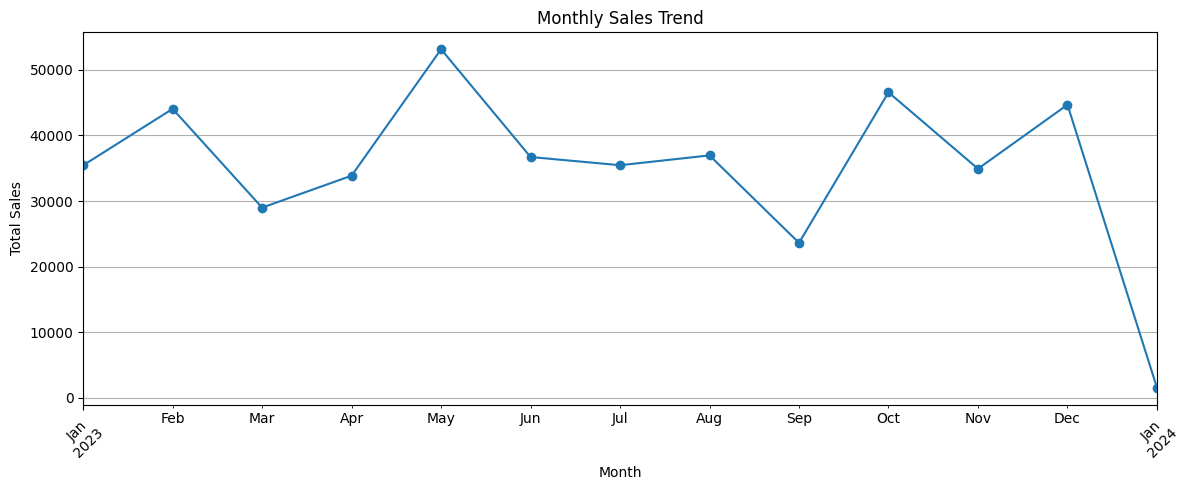

In [18]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()


### Observation

Monthly sales fluctuate throughout the period. Sales reached the highest
level in May 2023 with total sales of ₹53,150, while September 2023 recorded
the lowest sales among the full months with ₹23,620.

January 2024 records substantially lower sales than the preceding months,
which may indicate that the dataset contains only partial data for that month.

In [19]:
quarterly_sales = df.groupby(
    ['Year', 'Quarter']
)['Total Amount'].sum()

quarterly_sales

Year  Quarter
2023  1          108500
      2          123735
      3           96045
      4          126190
2024  1            1530
Name: Total Amount, dtype: int64

In [20]:
quarterly_sales_plot = quarterly_sales.reset_index()

In [21]:

quarterly_sales_plot['Quarter_Label'] = (
    quarterly_sales_plot['Year'].astype(str)
    + '-Q'
    + quarterly_sales_plot['Quarter'].astype(str)
)



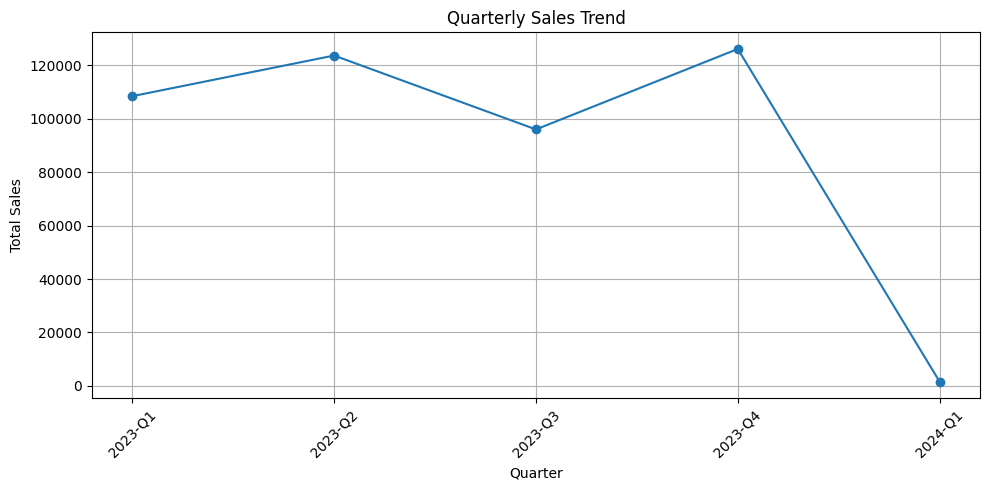

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    quarterly_sales_plot['Quarter_Label'],
    quarterly_sales_plot['Total Amount'],
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

### Quarterly Sales Trend - Observation

Quarterly sales fluctuated during 2023. Sales increased from ₹108,500 in Q1
to ₹123,735 in Q2, decreased to ₹96,045 in Q3, and then increased to the
highest full-quarter value of ₹126,190 in Q4.

The 2024 Q1 value of ₹1,530 is substantially lower because the dataset only
contains a partial period for January 2024.

In [23]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 25, 35, 45, 55, 65, 100],
    labels=['Below 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+'],
    right=False
)

age_groups = df['Age Group'].value_counts().sort_index()

age_groups

Age Group
Below 18      0
18-24       149
25-34       203
35-44       207
45-54       225
55-64       216
65+           0
Name: count, dtype: int64

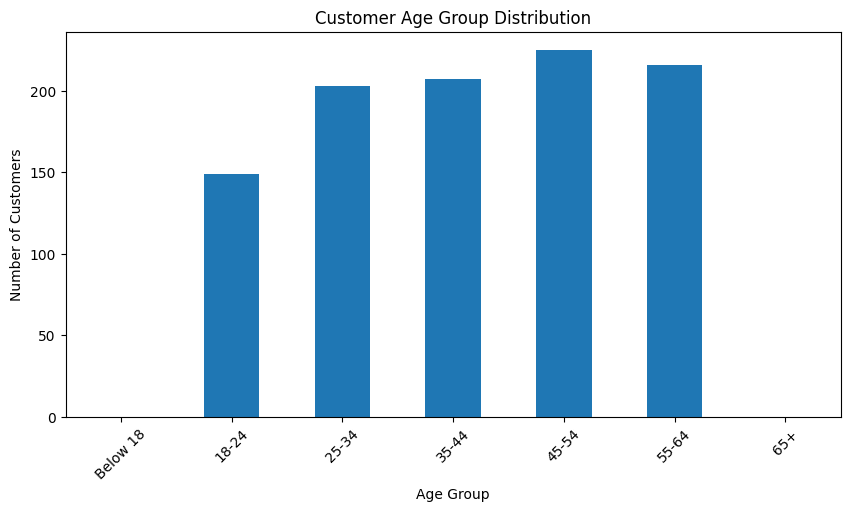

In [24]:
plt.figure(figsize=(10, 5))

age_groups.plot(kind='bar')

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

plt.show()

### Observation

The customer age distribution shows that the **45–54 age group has the highest representation with 225 customers**, followed by the **55–64 age group with 216 customers**.

The **35–44 age group contains 207 customers**, while the **25–34 age group contains 203 customers**. The **18–24 age group has 149 customers**, making it the smallest represented group among the observed age ranges.

This indicates that customers aged **45–64 form a significant portion of the customer base**. The business can consider targeted promotions and loyalty offers for this demographic while also developing campaigns to attract younger customers.

In [25]:
gender_counts = df['Gender'].value_counts()

gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

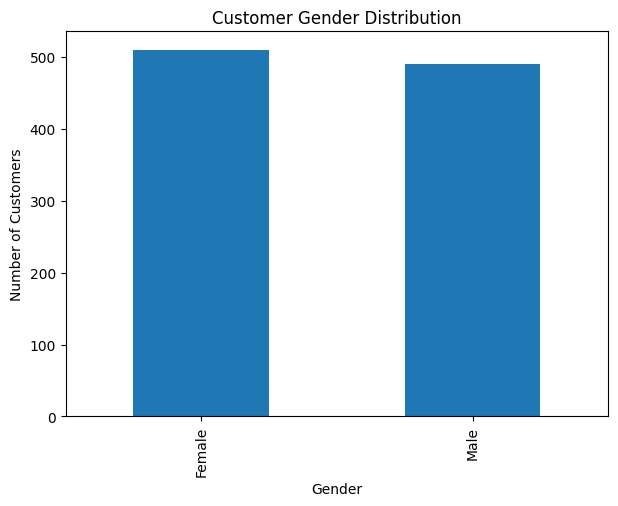

In [26]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind='bar')

plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

### Observation

The dataset contains **510 female customers and 490 male customers**.

Female customers represent a slightly larger portion of the customer base, accounting for approximately **51%** of customers, while male customers account for approximately **49%**.

The difference is relatively small, indicating that the customer base is **fairly balanced by gender**. Therefore, marketing strategies should target both groups rather than focusing heavily on one gender.

In [27]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Year', 'Month', 'Quarter', 'Age Group'],
      dtype='object')

In [28]:
category_sales = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

category_sales

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

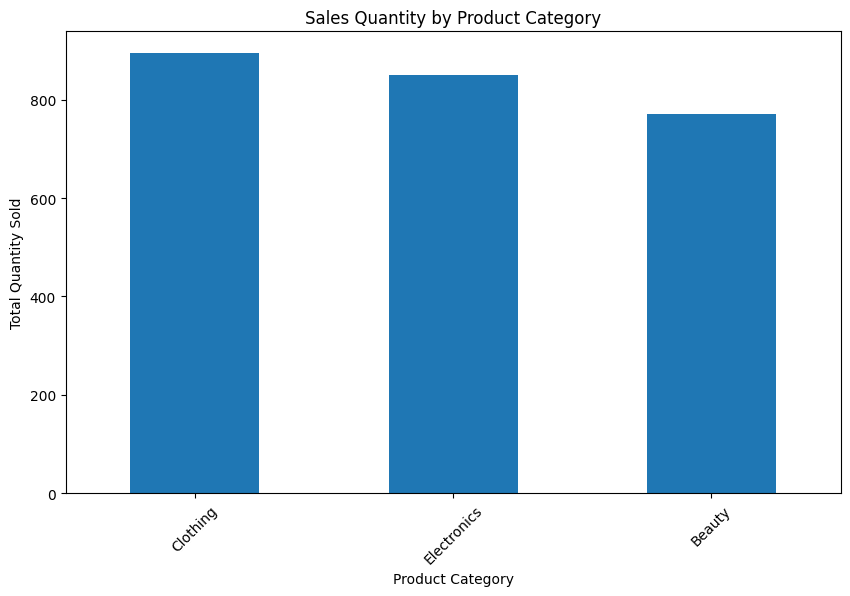

In [29]:
plt.figure(figsize=(10, 6))

category_sales.plot(kind='bar')

plt.title('Sales Quantity by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)

plt.show()

### Observation

Clothing is the **highest-selling product category by quantity**, with **894 units sold**.

Electronics follows with **849 units**, while Beauty has the lowest sales quantity among the three categories with **771 units**.

This indicates that Clothing has the strongest demand by sales volume. The business should ensure sufficient inventory for Clothing products and consider promotional strategies for the Beauty category to improve its sales volume.

In [30]:
category_revenue = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

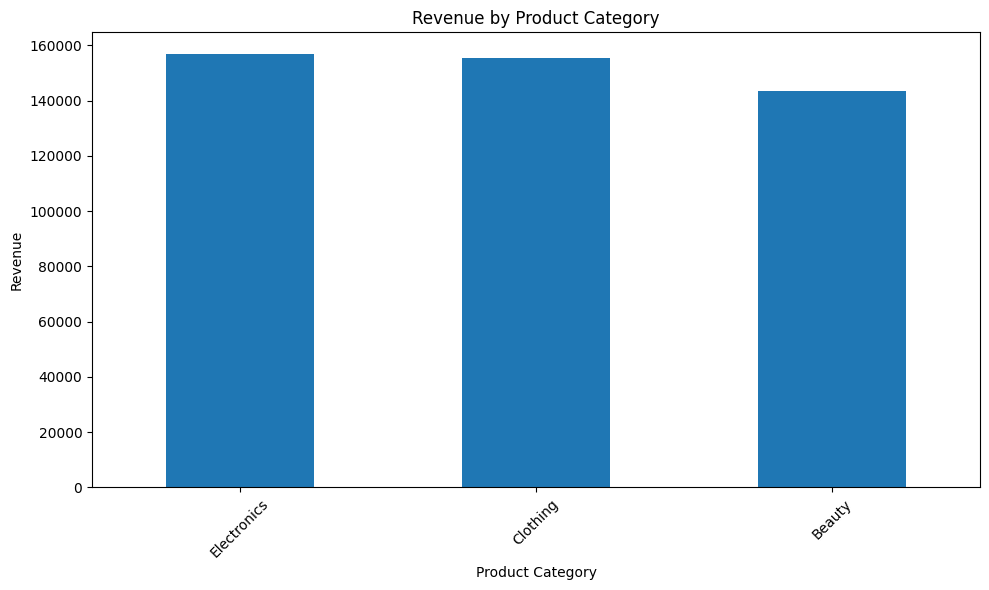

In [31]:
plt.figure(figsize=(10, 6))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

Electronics generates the **highest revenue at ₹156,905**, followed closely by Clothing at **₹155,580**.

Beauty generates **₹143,515**, which is the lowest revenue among the three categories.

The small difference between Electronics and Clothing indicates that both categories are important revenue contributors. Beauty has comparatively lower revenue and could be evaluated for pricing, promotions, product variety, and customer demand.

The business should prioritize inventory availability for Electronics and Clothing while exploring strategies to improve Beauty category performance.

In [32]:
top_categories = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_categories

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

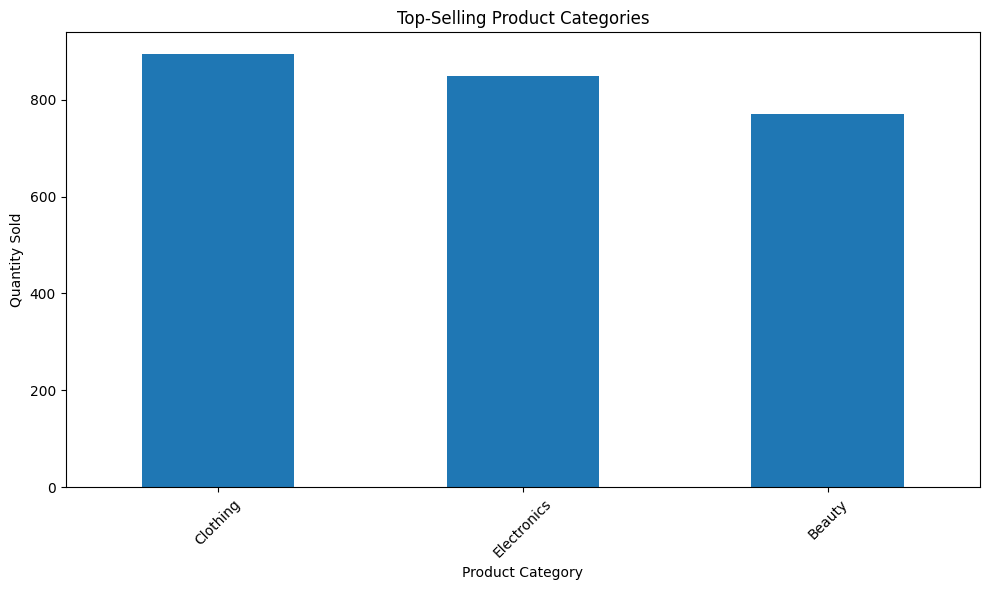

In [33]:
plt.figure(figsize=(10, 6))

top_categories.plot(kind='bar')

plt.title('Top-Selling Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Product-Level Analysis Limitation

The dataset does not contain an individual **Product Name** column. It only contains the **Product Category** column.

Therefore, an individual top-10 product analysis cannot be performed from this dataset without introducing unsupported information.

Instead, product-category sales analysis was performed using total quantity sold and revenue by product category. This provides a reliable view of category-level product demand.

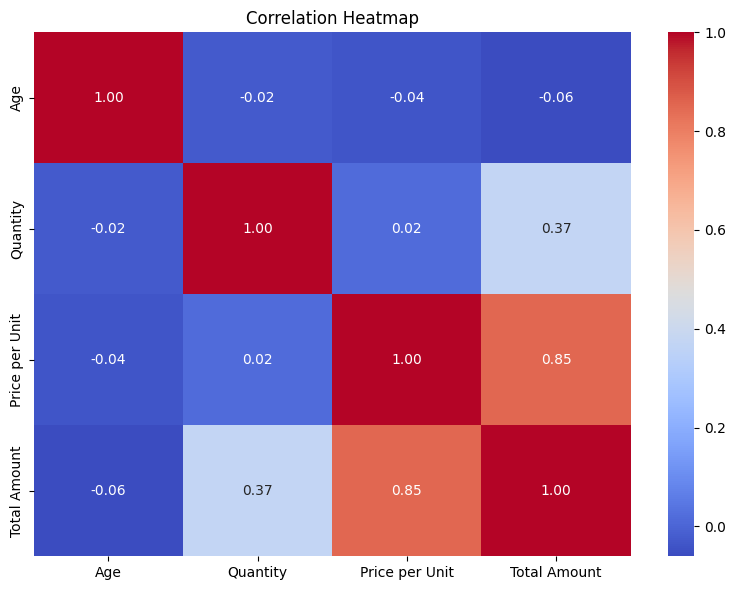

In [34]:
numerical_data = df[
    ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
]

correlation_matrix = numerical_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the relationships among **Age, Quantity, Price per Unit, and Total Amount**.

Total Amount has a strong positive relationship with Quantity and Price per Unit because transaction value depends on the number of units purchased and the price per unit.

Age shows comparatively weaker relationships with the sales-related variables. This suggests that customer age alone is not a strong indicator of transaction value.

Therefore, the business should consider multiple factors such as product category, quantity purchased, price, and customer demographics when analysing purchasing behaviour.

In [37]:
avg_transaction_by_age = (
    df.groupby('Age Group', observed=False)['Total Amount']
    .mean()
)

avg_transaction_by_age

Age Group
Below 18           NaN
18-24       501.006711
25-34       478.275862
35-44       467.801932
45-54       432.155556
55-64       417.546296
65+                NaN
Name: Total Amount, dtype: float64

In [ ]:
plt.figure(figsize=(10, 6))

avg_transaction_by_age.plot(kind='bar')

plt.title('Average Transaction Value by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Transaction Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The **18–24 age group has the highest average transaction value at approximately ₹501.01**.

This is followed by the **25–34 age group at approximately ₹478.28** and the **35–44 age group at approximately ₹467.80**.

The **45–54 age group has an average transaction value of approximately ₹432.16**, while the **55–64 age group has approximately ₹417.55**.

Although the 45–54 age group has the largest number of customers, younger customers show higher average transaction values. This indicates that customer count and transaction value should be analysed separately when designing marketing strategies.

# Conclusion and Business Recommendations

## Conclusion

The exploratory data analysis provided insights into **sales trends, customer demographics, product-category performance, and transaction values**.

The dataset contains **1,000 retail transactions**. Sales fluctuate across months and quarters, with **May 2023 recording the highest monthly sales of ₹53,150**.

The **45–54 age group is the largest customer segment with 225 customers**, while the **18–24 age group has the highest average transaction value at approximately ₹501.01**.

Among product categories, **Clothing has the highest sales quantity with 894 units**, while **Electronics generates the highest revenue at ₹156,905**.

## Business Recommendations

1. **Prioritize high-performing categories:**  
   Maintain sufficient inventory and marketing support for Clothing and Electronics because they demonstrate strong sales volume and revenue performance.

2. **Target high-value customer segments:**  
   The 18–24 and 25–34 age groups have higher average transaction values. Targeted offers, bundles, and loyalty campaigns can be used to increase their purchase frequency.

3. **Develop strategies for lower-performing categories:**  
   Beauty generates the lowest category revenue at ₹143,515. The business can evaluate pricing, promotions, product assortment, and customer preferences to improve its performance.

4. **Use sales trends for inventory planning:**  
   Monthly and quarterly fluctuations should be considered when planning inventory and promotional campaigns. Higher-performing periods can be supported with adequate stock and targeted promotions.

5. **Use multiple customer attributes for marketing:**  
   Customer age and gender alone should not determine marketing decisions. Product category, transaction value, quantity purchased, and purchasing patterns should also be considered.